In [35]:
import geopandas as gpd
import pandas as pd

In [36]:
canada_gauges = gpd.read_file("shp/canada_gages_3338.shp")
alaska_gauges = gpd.read_file("shp/ak_active_gages_3338.shp")

In [37]:
canada_gauges = canada_gauges[
    ["Station ID", "Station Na", "Latitude", "Longitude", "COMID", "geometry"]
]
ak_gauges = alaska_gauges[
    ["site_no", "station_nm", "dec_lat_va", "dec_long_v", "COMID", "geometry"]
]

In [ ]:
# Rename columns to match
canada_gauges.columns = ["ID", "Name", "Latitude", "Longitude", "COMID", "geometry"]
ak_gauges.columns = ["ID", "Name", "Latitude", "Longitude", "COMID", "geometry"]
# Merge the two GeoDataFrames
merged_gauges = gpd.GeoDataFrame(
    pd.concat([canada_gauges, ak_gauges], ignore_index=True), crs=canada_gauges.crs
)
merged_gauges

,ID,Name,Latitude,Longitude,COMID,geometry
0,09AA004,BENNETT LAKE AT CARCROSS,60.16389,-134.7075,81032395,POINT (1052184.668 1284534.673)
1,09AA006,ATLIN RIVER NEAR ATLIN,59.59536,-133.81442,81033944,POINT (1118446.037 1238337.387)
2,09AA012,WHEATON RIVER NEAR CARCROSS,60.12778,-134.88361,81032859,POINT (1043994.408 1277884.511)
3,09AA013,TUTSHI RIVER AT OUTLET OF TUTSHI LAKE,59.94778,-134.3325,81034135,POINT (1079094.569 1267415.266)
4,09AB001,YUKON RIVER AT WHITEHORSE,60.7445,-135.06403,81030832,POINT (1015009.006 1341252.724)
...,...,...,...,...,...,...
140,15747000,WULIK R BL TUTAK C NR KIVALINA AK,67.87547519,-163.677559,81005569,POINT (-408523.808 2020458.919)
141,15875000,COLVILLE R AT UMIAT AK,69.3605,-152.1226944,81001685,POINT (74884.972 2155626.519)
142,15896000,KUPARUK R NR DEADHORSE AK,70.2813799,-148.962861,81000404,POINT (193102.347 2262999.808)
143,15905100,ATIGUN R BL GALBRAITH LK NR PUMP STATION 4 AK,68.4522222,-149.3733333,81003397,POINT (191402.544 2061090.423)


<Axes: >

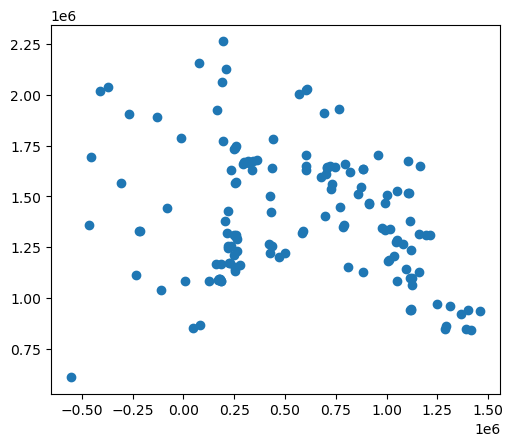

In [45]:
merged_gauges.plot()

In [39]:
canada_watersheds = gpd.read_file("shp/YT_watersheds_to_merge.shp")
alaska_watersheds = gpd.read_file("shp/alaska_huc8_to_merge.shp")

In [40]:
canada_watersheds = canada_watersheds[["id", "name", "sub_en", "geometry"]]
alaska_watersheds = alaska_watersheds[["huc8", "huc8", "name", "geometry"]]

In [ ]:
# Rename columns to match
canada_watersheds.columns = ["ID_1", "ID_2", "Name", "geometry"]
alaska_watersheds.columns = ["ID_1", "ID_2", "Name", "geometry"]

# Use 3338 as the CRS for both GeoDataFrames
canada_watersheds = canada_watersheds.to_crs(epsg=3338)
alaska_watersheds = alaska_watersheds.to_crs(epsg=3338)

# Merge the two GeoDataFrames
merged_watersheds = gpd.GeoDataFrame(
    pd.concat([canada_watersheds, alaska_watersheds], ignore_index=True),
    crs=canada_watersheds.crs,
)
merged_watersheds

,ID_1,ID_2,Name,geometry
0,YTHYDRO1,09CD,Upper Yukon - White,"POLYGON ((729800.052 1497146.843, 729685.999 1..."
1,YTHYDRO2,09DB,Beaver (Y.T.),"POLYGON ((1054595.352 1712269.343, 1054497.34 ..."
2,YTHYDRO4,09BC,Lower Pelly,"POLYGON ((942829.263 1500641.895, 942757.706 1..."
3,YTHYDRO8,09CA,Donjek,"POLYGON ((743965.646 1372334.937, 743634.991 1..."
4,YTHYDRO13,09AH,Headwaters Yukon - Nordenskiold,"POLYGON ((1013432.946 1473311.461, 1013257.651..."
...,...,...,...,...
137,19060103,19060103,Utukok River,"POLYGON ((-250116.014 2292021.095, -246316.643..."
138,19050403,19050403,Lower Noatak River,"POLYGON ((-308157.378 2087097.066, -308126.289..."
139,19060101,19060101,Kukpowruk River,"POLYGON ((-355401.864 2212084.341, -355401.837..."
140,19080101,19080101,Headwaters Porcupine River,"POLYGON ((648120.815 2020404.181, 648174.977 2..."


<Axes: >

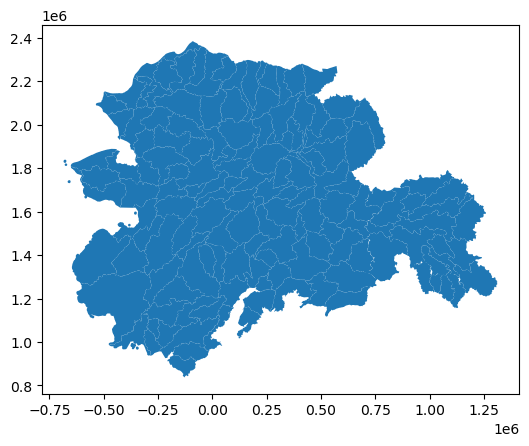

In [44]:
merged_watersheds.plot()

In [50]:
segments = gpd.read_file("shp/arctic_segments.shp")
segments.to_crs(epsg=3338, inplace=True)

<Axes: >

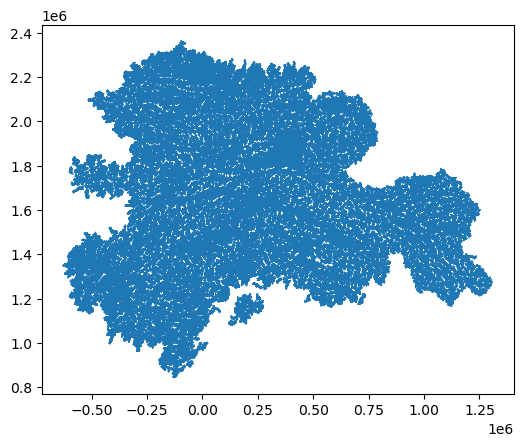

In [51]:
segments.plot()

In [57]:
# join gauge ID to segments using COMID
# guard against missing COMIDs
merged_gauges["COMID"] = merged_gauges["COMID"].astype(pd.Int64Dtype())
segments_with_gauges = segments.merge(
    merged_gauges[["ID", "COMID"]], left_on="COMID", right_on="COMID", how="left"
)
# print the segments that have gauges
segments_with_gauges[segments_with_gauges["ID"].notnull()]

,COMID,geometry,ID
318,81000404,"LINESTRING (192479.454 2264631.586, 192454.486...",15896000
1435,81001685,"LINESTRING (76259.899 2157812.362, 76262.54 21...",15875000
2286,81002548,"LINESTRING (212001.836 2132539.331, 211975.577...",15908000
3116,81003397,"LINESTRING (200400.325 2068132.012, 200393.601...",15905100
4820,81005122,"LINESTRING (-374745.871 2039664.731, -374723.5...",15746988
...,...,...,...
32149,81034026,"LINESTRING (1209937.204 1304065.002, 1209981.1...",09AE003
32224,81034135,"LINESTRING (1083805.801 1263755.059, 1083778.5...",09AA013
32316,81034271,"LINESTRING (124157.807 1087058.945, 124204.448...",15239900
32317,81034272,"LINESTRING (7374.859 1084247.707, 7421.721 108...",15300300


In [ ]:
# print just gauge IDs
for segment in segments_with_gauges[segments_with_gauges["ID"].notnull()]["ID"]:
    print(segment)
# if gauges start with 09, they are Canadian, if they start with 15, they are Alaskan

15896000
15875000
15908000
15905100
15746988
09FD003
09FC001
15747000
09FD002
15564879
15744500
15743850
09FA001
09FB002
15453500
15564900
15446000
15519100
15457790
15519030
15356000
15485500
15580095
15514000
15493700
15493400
15493000
15511000
15515500
15348000
15484000
15477740
09EB001
09DB001
09EB003
09EA003
09EA006
15565700
09EA004
09EA005
15515060
15320100
09DC006
09DA001
09DD004
09DC007
09EB004
09CD001
09DD003
15303600
15478040
09BC001
15292000
09AH003
09BB001
09AH001
09BC004
09AH004
15200280
09CA006
15292700
09AH005
15565447
15304000
09BC002
09BA001
15304010
09AG001
09CB001
15294005
15283700
09CA002
15284000
15281000
15209700
09CA004
15290000
15209770
09AC001
15227090
15271000
15226620
15214000
09AB001
15266300
15266110
15258000
15261000
09AD002
09AC007
09AE002
09AA004
09AE006
15243900
09AA012
09AA006
15302000
09AE003
09AA013
15239900
15300300
15300500


In [62]:
# find which watershed the segments are in
# use the majority of the segment's geometry to determine which watershed it is in
segments_with_watersheds = gpd.sjoin(
    segments_with_gauges, merged_watersheds, how="left", predicate="intersects"
)
segments_with_watersheds

,COMID,geometry,ID,index_right,ID_1,ID_2,Name
0,81000004,"LINESTRING (-55856.646 2319023.49, -55825.464 ...",NaN,49.0,19060206,19060206,Admiralty Bay-Dease Inlet
1,81000005,"LINESTRING (-72325.339 2318174.181, -72353.885...",NaN,47.0,19060203,19060203,Meade River
2,81000006,"LINESTRING (-78833.372 2317734.927, -78864.57 ...",NaN,47.0,19060203,19060203,Meade River
3,81000007,"LINESTRING (-90884.13 2319602.765, -90852.955 ...",NaN,47.0,19060203,19060203,Meade River
4,81000011,"LINESTRING (-74827.753 2325254.816, -74856.112...",NaN,47.0,19060203,19060203,Meade River
...,...,...,...,...,...,...,...
34203,82001686,"LINESTRING (503536.419 2174114.986, 503503.419...",NaN,135.0,19060504,19060504,Kongakut River-Beaufort Lagoon
34204,82001698,"LINESTRING (439802.938 2164756.785, 439836.056...",NaN,135.0,19060504,19060504,Kongakut River-Beaufort Lagoon
34205,82001703,"LINESTRING (506930.337 2180283.117, 506947.749...",NaN,135.0,19060504,19060504,Kongakut River-Beaufort Lagoon
34206,82001706,"LINESTRING (473546.263 2170601.877, 473529.464...",NaN,135.0,19060504,19060504,Kongakut River-Beaufort Lagoon


In [ ]:
# rename the gauge ID column
segments_with_watersheds.rename(columns={"ID": "Gauge_ID"}, inplace=True)
# drop the index_right column from the spatial join
segments_with_watersheds.drop(columns=["index_right"], inplace=True)
segments_with_watersheds

,COMID,geometry,Gauge_ID,ID_1,ID_2,Name
0,81000004,"LINESTRING (-55856.646 2319023.49, -55825.464 ...",NaN,19060206,19060206,Admiralty Bay-Dease Inlet
1,81000005,"LINESTRING (-72325.339 2318174.181, -72353.885...",NaN,19060203,19060203,Meade River
2,81000006,"LINESTRING (-78833.372 2317734.927, -78864.57 ...",NaN,19060203,19060203,Meade River
3,81000007,"LINESTRING (-90884.13 2319602.765, -90852.955 ...",NaN,19060203,19060203,Meade River
4,81000011,"LINESTRING (-74827.753 2325254.816, -74856.112...",NaN,19060203,19060203,Meade River
...,...,...,...,...,...,...
34203,82001686,"LINESTRING (503536.419 2174114.986, 503503.419...",NaN,19060504,19060504,Kongakut River-Beaufort Lagoon
34204,82001698,"LINESTRING (439802.938 2164756.785, 439836.056...",NaN,19060504,19060504,Kongakut River-Beaufort Lagoon
34205,82001703,"LINESTRING (506930.337 2180283.117, 506947.749...",NaN,19060504,19060504,Kongakut River-Beaufort Lagoon
34206,82001706,"LINESTRING (473546.263 2170601.877, 473529.464...",NaN,19060504,19060504,Kongakut River-Beaufort Lagoon


In [64]:
merged_gauges.to_file("export/arctic_rivers_gauges_3338.shp")
merged_watersheds.to_file("export/arctic_rivers_watersheds_3338.shp")
segments_with_watersheds.to_file("export/arctic_rivers_segments_3338.shp")